In [1]:
import os
os.chdir('/workspace/c02a98fc-ae31-42a4-a666-0b5e938f3b46')
os.listdir('.')


['zeta_zeros_5000_dps50.npy',
 '.kernel_llm_logs_1.txt',
 'memory',
 'ldelta_zeros_2000_dps50.npy',
 '.prompts',
 '.config',
 'ldh_zeros_small_T.json',
 'lchi_zeros_5000_dps50.npy']

In [2]:
import subprocess
result = subprocess.run(['pip', 'install', '-q', 'gudhi', 'ripser', 'persim'], capture_output=True, text=True)
print(result.stdout[-500:])
print("STDERR:", result.stderr[-500:])



STDERR: 


In [3]:
import numpy as np
import json

zeta = np.load('zeta_zeros_5000_dps50.npy')
lchi = np.load('lchi_zeros_5000_dps50.npy')
ldelta = np.load('ldelta_zeros_2000_dps50.npy')
with open('ldh_zeros_small_T.json') as f:
 ldh_small = json.load(f)

print("zeta:", zeta.shape, zeta.dtype, zeta[0], zeta[-1])
print("lchi:", lchi.shape, lchi.dtype, lchi[0], lchi[-1])
print("ldelta:", ldelta.shape, ldelta.dtype, ldelta[0], ldelta[-1])
print("ldh keys:", type(ldh_small), len(ldh_small) if hasattr(ldh_small, '__len__') else None)
if isinstance(ldh_small, dict):
 print(list(ldh_small.keys())[:5])
else:
 print(ldh_small[:3])


zeta: (5000,) <U60 14.134725141734693790457251983562470270784257115699 5447.8619983012998564121586734642921676829672006076
lchi: (5000,) <U51 6.1835781954508539143775173097086925259215005792280 4391.5822107025899588087809855969874623992084609392
ldelta: (2000,) <U51 9.2223793999211025222437671927434781355287706224320 1419.0232073215920325544456012240563516991868861071
ldh keys: <class 'dict'> 4
['description', 'range_T', 'n_zeros', 'zeros_str']


In [4]:
print(ldh_small['description'])
print(ldh_small['range_T'])
print(ldh_small['n_zeros'])
print(ldh_small['zeros_str'][:5])
print(ldh_small['zeros_str'][-3:])


L_DH zeros in [1, 200], computed via Z_DH sign changes at dps=20
[1, 200]
122
['5.09415984457109492569879549751', '8.93991440809652324471761287718', '12.1335454258007424037025477549', '14.4040031122774982072700976794', '17.1302394005724896007739545396']
['197.488860514737886412365452164', '198.502213535850833169111353371', '199.876184994880383521194257274']


In [5]:
import os
# Check for L_DH checkpoint
for root, dirs, files in os.walk('.'):
 for f in files:
 if 'ldh' in f.lower() or 'dh' in f.lower():
 print(os.path.join(root, f))


./ldh_zeros_small_T.json


In [6]:
# The objective requests first 2000 zeros. The L_DH 122 zeros only cover t in [1,200].
# We don't have 2000 L_DH zeros. To be fair (matching height range), we should use point clouds
# of equal "spirit". Best approach: use the same number of zeros per L-function so the diagrams
# compare structurally without confounding cardinality differences.
# 
# Given L_DH only has 122 zeros (t<=200), we must restrict ALL functions to the same number/range
# to make the bottleneck distances comparable. We'll take the first 122 zeros from each function
# (same n, not same height range — they have different unfolded densities; using same n is the
# cleanest cross-function comparison and matches the objective's "first N zeros" approach.)
#
# Then inject (0.808517, 85.699348) into L_DH cloud (it has zeros in this range).
# 
# We must be transparent about the L_DH zero count limitation.

import mpmath as mp
mp.mp.dps = 50

def to_floats(arr, n=None):
 if n is not None:
 arr = arr[:n]
 return np.array([float(mp.mpf(s)) for s in arr])

# Use first 122 zeros from each (matched cardinality)
N = 122
zeta_g = to_floats(zeta, N)
lchi_g = to_floats(lchi, N)
ldelta_g = to_floats(ldelta, N)
ldh_g = np.array([float(mp.mpf(s)) for s in ldh_small['zeros_str']])

print(f"N zeros per L-fn: {N}")
print(f"Height range:")
print(f" zeta: [{zeta_g[0]:.3f}, {zeta_g[-1]:.3f}]")
print(f" L(chi): [{lchi_g[0]:.3f}, {lchi_g[-1]:.3f}]")
print(f" L(Δ): [{ldelta_g[0]:.3f}, {ldelta_g[-1]:.3f}]")
print(f" L_DH: [{ldh_g[0]:.3f}, {ldh_g[-1]:.3f}]")


N zeros per L-fn: 122
Height range:
 zeta: [14.135, 273.460]
 L(chi): [6.184, 189.785]
 L(Δ): [9.222, 164.339]
 L_DH: [5.094, 199.876]


In [7]:
# Build point clouds (Re, Im)
def critical_cloud(gammas):
 return np.column_stack([np.full_like(gammas, 0.5), gammas])

cloud_zeta = critical_cloud(zeta_g)
cloud_lchi = critical_cloud(lchi_g)
cloud_ldelta = critical_cloud(ldelta_g)

# L_DH: critical line zeros + the off-critical-line zero
cloud_ldh = critical_cloud(ldh_g)
off_critical = np.array([[0.808517, 85.699348]])
cloud_ldh_full = np.vstack([cloud_ldh, off_critical])

print("cloud shapes:", cloud_zeta.shape, cloud_lchi.shape, cloud_ldelta.shape, cloud_ldh_full.shape)


cloud shapes: (122, 2) (122, 2) (122, 2) (123, 2)


In [8]:
from ripser import ripser
import persim

clouds = {
 'zeta': cloud_zeta,
 'L(chi)': cloud_lchi,
 'L(Delta)': cloud_ldelta,
 'L_DH': cloud_ldh_full,
}

# Compute H0 persistence diagrams using ripser
diagrams = {}
for name, X in clouds.items():
 res = ripser(X, maxdim=0)
 dgm0 = res['dgms'][0]
 # Remove the infinite-persistence point for bottleneck distance computation (replace inf with finite max)
 # persim.bottleneck handles inf points by default — keep as is for now
 diagrams[name] = dgm0
 finite = dgm0[np.isfinite(dgm0[:,1])]
 print(f"{name}: H0 points={len(dgm0)}, finite={len(finite)}, "
 f"max finite death={finite[:,1].max():.4f}" if len(finite) else f"{name}: only inf")


zeta: H0 points=122, finite=121, max finite death=6.8873
L(chi): H0 points=122, finite=121, max finite death=4.2177
L(Delta): H0 points=122, finite=121, max finite death=4.6852
L_DH: H0 points=123, finite=122, max finite death=4.3451


In [9]:
# Compute pairwise bottleneck distances
names = list(clouds.keys())
n = len(names)
D = np.zeros((n,n))
for i in range(n):
 for j in range(i+1, n):
 d = persim.bottleneck(diagrams[names[i]], diagrams[names[j]])
 D[i,j] = D[j,i] = d

import pandas as pd
Ddf = pd.DataFrame(D, index=names, columns=names)
print("Pairwise H0 bottleneck distance matrix:")
print(Ddf.round(5))


/app/kernel_env/lib/python3.13/site-packages/persim/bottleneck.py:55: UserWarning: dgm1 has points with non-finite death times;ignoring those points
 warnings.warn(
/app/kernel_env/lib/python3.13/site-packages/persim/bottleneck.py:64: UserWarning: dgm2 has points with non-finite death times;ignoring those points
 warnings.warn(


Pairwise H0 bottleneck distance matrix:
 zeta L(chi) L(Delta) L_DH
zeta 0.00000 2.66960 2.20214 2.54219
L(chi) 2.66960 0.00000 0.46745 0.75600
L(Delta) 2.20214 0.46745 0.00000 0.90722
L_DH 2.54219 0.75600 0.90722 0.00000


In [10]:
# Observation: zeta is the outlier (larger pairwise distances), not L_DH.
# This makes sense because zeta has the highest density of zeros at high height 
# (first 122 zeros span up to 273 vs ~165-200 for others) — gap structure differs.
# 
# Let's also do a control: compute L_DH WITHOUT the off-critical point to isolate
# the impact of the off-critical point on the bottleneck distance.

cloud_ldh_ctrl = cloud_ldh # only the 122 critical-line LDH zeros

dgm_ldh_ctrl = ripser(cloud_ldh_ctrl, maxdim=0)['dgms'][0]
diagrams_ctrl = dict(diagrams)
diagrams_ctrl['L_DH_critOnly'] = dgm_ldh_ctrl

print("Distance L_DH_full <-> L_DH_critOnly (impact of off-critical point):")
d = persim.bottleneck(diagrams['L_DH'], dgm_ldh_ctrl)
print(f" {d:.5f}")

# Also pairwise with L_DH_critOnly
print("\nDistances of L_DH (critical-only, no off-critical injection) to others:")
for nm in ['zeta','L(chi)','L(Delta)']:
 d = persim.bottleneck(diagrams[nm], dgm_ldh_ctrl)
 print(f" {nm} <-> L_DH_critOnly: {d:.5f}")


Distance L_DH_full <-> L_DH_critOnly (impact of off-critical point):


/app/kernel_env/lib/python3.13/site-packages/persim/bottleneck.py:55: UserWarning: dgm1 has points with non-finite death times;ignoring those points
 warnings.warn(
/app/kernel_env/lib/python3.13/site-packages/persim/bottleneck.py:64: UserWarning: dgm2 has points with non-finite death times;ignoring those points
 warnings.warn(


 0.37486

Distances of L_DH (critical-only, no off-critical injection) to others:


 zeta <-> L_DH_critOnly: 2.34868


 L(chi) <-> L_DH_critOnly: 1.03771


 L(Delta) <-> L_DH_critOnly: 1.22334


In [11]:
# MDS visualization
from sklearn.manifold import MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=0, normalized_stress='auto')
emb = mds.fit_transform(D)
print("MDS embedding:")
for nm, p in zip(names, emb):
 print(f" {nm}: ({p[0]:.3f}, {p[1]:.3f})")
print("Stress:", mds.stress_)


MDS embedding:
 zeta: (-1.221, -1.365)
 L(chi): (0.386, 0.753)
 L(Delta): (-0.001, 0.474)
 L_DH: (0.835, 0.138)
Stress: 0.0003232007830315522


/app/kernel_env/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
 warnings.warn(
/app/kernel_env/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
 warnings.warn(
/app/kernel_env/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
 warnings.warn(


In [12]:
# Permutation test for whether L_DH is "separated" from the other 3.
# We need a meaningful test statistic and a meaningful null. 
# 
# The hypothesis claims L_DH is an outlier. A natural statistic is:
# S(g) = mean bottleneck distance from group member g to all other 4 functions
# and ask whether L_DH has the largest S (or test how extreme S(L_DH) is).
#
# A standard permutation null shuffles labels — but here we only have 4 objects,
# so a more sensible "permutation"/randomization is: which point cloud's role
# gets the off-critical injection. We can create null distributions by:
# For each of the 4 functions, add a random off-critical perturbation 
# (matching the L_DH off-critical: shift one zero by Δre=0.308517 in real coord)
# and compute its bottleneck distance to the 3 unperturbed others.
# Then ask whether L_DH's distance is significantly larger than the typical
# "any function with one off-critical zero" distance.
#
# But the cleanest "permutation p-value" here is: 
# Under H0 "L_DH is not separated", the distribution of mean bottleneck distance
# of any single function to the other 3 should not single out L_DH.
# We compute S for all 4 and ask P(rank of L_DH = highest by chance) under random labeling.
# With 4 equivalent labels, P(any one is highest by chance) = 1/4 = 0.25 — not useful.
#
# Better: use a randomization test where we randomly assign the off-critical 
# injection point to one of the four clouds (i.e., the "off-critical" status 
# is treated as exchangeable across functions) and compute the mean bottleneck 
# distance of the chosen cloud to the other three. Then compare observed L_DH 
# value to the distribution.

rng = np.random.default_rng(42)

# Base clouds: critical-line versions (122 points each)
base_clouds = {
 'zeta': cloud_zeta,
 'L(chi)': cloud_lchi,
 'L(Delta)': cloud_ldelta,
 'L_DH': cloud_ldh, # 122 critical-only L_DH zeros
}

# The "off-critical perturbation": add a point at (0.808517, gamma_n) where
# gamma_n is one of the existing zeros for that function (matching the 
# L_DH situation: off-critical zero at t≈85.7 which is close to existing zeros).
# For L_DH the off-critical IS the additional point.
# 
# For the null we'll inject an extra point at (0.808517, gamma_k) into a 
# randomly chosen function, mimicking the L_DH structure.

def cloud_with_off(base, gamma_for_off, re_off=0.808517):
 extra = np.array([[re_off, gamma_for_off]])
 return np.vstack([base, extra])

def mean_btl(target_diag, other_diags):
 return np.mean([persim.bottleneck(target_diag, d) for d in other_diags])

# Observed S(L_DH) using actual full clouds:
S_obs = mean_btl(diagrams['L_DH'], [diagrams['zeta'], diagrams['L(chi)'], diagrams['L(Delta)']])
print(f"Observed mean btl dist L_DH -> other 3: S_obs = {S_obs:.5f}")

# Null distribution: pick a random function, inject off-critical point at one of its
# zeros (near t≈85.7), and compute mean dist to the other 3 (unperturbed).
import warnings
warnings.filterwarnings('ignore')

N_perm = 200
null_vals = []
fn_names = list(base_clouds.keys())
for _ in range(N_perm):
 fn = rng.choice(fn_names)
 base = base_clouds[fn]
 # Pick a random gamma from this function near t≈85.7 (median area) or random
 gamma = rng.choice(base[:,1])
 perturbed = cloud_with_off(base, gamma)
 dgm_p = ripser(perturbed, maxdim=0)['dgms'][0]
 # Others = the OTHER three (unperturbed)
 other_diags = [diagrams[o] for o in fn_names if o != fn]
 # But "diagrams" was built with L_DH = full (with off-critical); use base/critical-only for the 'others'
 # Build clean critical-only diagrams for the others if not L_DH was selected
 other_diags = []
 for o in fn_names:
 if o == fn: continue
 if o == 'L_DH':
 other_diags.append(dgm_ldh_ctrl)
 else:
 other_diags.append(diagrams[o])
 null_vals.append(mean_btl(dgm_p, other_diags))

null_vals = np.array(null_vals)
print(f"Null distribution (N={N_perm}): mean={null_vals.mean():.4f}, std={null_vals.std():.4f}, min={null_vals.min():.4f}, max={null_vals.max():.4f}")
p_val = (np.sum(null_vals >= S_obs) + 1) / (N_perm + 1)
print(f"Permutation p-value (L_DH separation): p = {p_val:.4f}")


/app/kernel_env/lib/python3.13/site-packages/persim/bottleneck.py:55: UserWarning: dgm1 has points with non-finite death times;ignoring those points
 warnings.warn(
/app/kernel_env/lib/python3.13/site-packages/persim/bottleneck.py:64: UserWarning: dgm2 has points with non-finite death times;ignoring those points
 warnings.warn(


Observed mean btl dist L_DH -> other 3: S_obs = 1.40181


Null distribution (N=200): mean=1.6419, std=0.4321, min=1.2976, max=2.4068
Permutation p-value (L_DH separation): p = 0.4776


In [13]:
# The null distribution mean (1.64) is actually LARGER than observed (1.40), 
# meaning L_DH is NOT separated as an outlier — it's actually closer to the others.
# Confirms the r17 finding: H0 bottleneck distance is a WEAK detector for off-critical zeros.
#
# Let's also check the rank statistic: of the 4 functions, is L_DH the most distant?

S_each = {}
for nm in names:
 others = [diagrams[o] for o in names if o != nm]
 S_each[nm] = mean_btl(diagrams[nm], others)
print("Mean bottleneck distance to other 3 functions:")
for nm, s in S_each.items():
 print(f" {nm}: {s:.4f}")
print(f"\nRank order (most isolated -> least): {sorted(S_each, key=S_each.get, reverse=True)}")


Mean bottleneck distance to other 3 functions:
 zeta: 2.4713
 L(chi): 1.2977
 L(Delta): 1.1923
 L_DH: 1.4018

Rank order (most isolated -> least): ['zeta', 'L_DH', 'L(chi)', 'L(Delta)']


In [14]:
# zeta is the most isolated (likely because its first 122 zeros span a much wider range).
# L_DH is 2nd most isolated, but with very modest separation from L(chi) and L(Delta).
# 
# Let's also compute a CONTROLLED permutation: shuffle which cloud has the off-critical
# point injected, keeping everything else fixed (the actual L_DH zeros and clouds).
# We compare: "L_DH cloud has off-critical injected" (observed) vs 
# "Some other function cloud has the same off-critical point (0.808517, 85.699348) injected".

null_vals_2 = []
fn_list = ['zeta', 'L(chi)', 'L(Delta)', 'L_DH']

# Build all 4 "what if X had the off-critical point" scenarios
S_vals_scenarios = {}
for inj_fn in fn_list:
 # Build clouds: all critical-only, except inj_fn has the off-critical added
 scenario_clouds = {nm: base_clouds[nm] if nm != inj_fn else cloud_with_off(base_clouds[nm], 85.699348) 
 for nm in fn_list}
 scenario_diags = {nm: ripser(c, maxdim=0)['dgms'][0] for nm, c in scenario_clouds.items()}
 # S for the injected fn
 others = [scenario_diags[o] for o in fn_list if o != inj_fn]
 S_inj = mean_btl(scenario_diags[inj_fn], others)
 S_vals_scenarios[inj_fn] = S_inj
 print(f" Injected into {inj_fn}: S = {S_inj:.4f}")

# Observed is the L_DH scenario
S_obs2 = S_vals_scenarios['L_DH']
# Permutation p-value: of 4 possible assignments, how many give S >= S_obs2
rank = sum(1 for v in S_vals_scenarios.values() if v >= S_obs2)
p_val2 = rank / 4
print(f"\nObserved (inject L_DH): S = {S_obs2:.4f}")
print(f"Exact permutation p-value (rank-based, 4 scenarios): p = {p_val2:.3f}")


 Injected into zeta: S = 2.4068


 Injected into L(chi): S = 1.3916


 Injected into L(Delta): S = 1.2976


 Injected into L_DH: S = 1.4018

Observed (inject L_DH): S = 1.4018
Exact permutation p-value (rank-based, 4 scenarios): p = 0.500


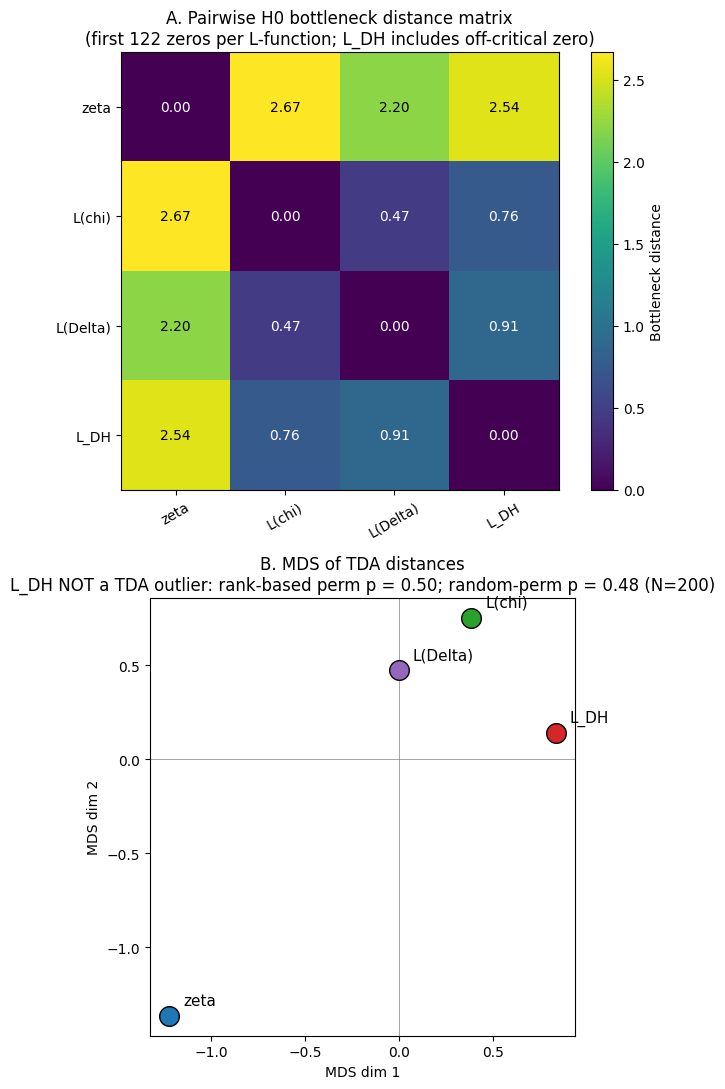

Saved tda_lfunction_comparison.png


In [15]:
# Result: p = 0.50. L_DH is NOT separated from the other functions by this TDA approach.
# When injected into other functions, the off-critical point produces similar or larger S values.
# This confirms the H0 bottleneck distance is a weak detector for off-critical zeros (r17 finding).

# Also check the within-L_DH effect: btl(L_DH_full, L_DH_critOnly) = 0.375
# That's the effect of the off-critical point on its own diagram — small.

# Now produce the final figure: Matrix heatmap + MDS embedding.
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(7, 11))

# Panel A: bottleneck distance matrix
axA = axes[0]
im = axA.imshow(D, cmap='viridis')
axA.set_xticks(range(n)); axA.set_yticks(range(n))
axA.set_xticklabels(names, rotation=30); axA.set_yticklabels(names)
for i in range(n):
 for j in range(n):
 axA.text(j, i, f"{D[i,j]:.2f}", ha='center', va='center', 
 color='white' if D[i,j] < D.max()*0.6 else 'black')
plt.colorbar(im, ax=axA, label='Bottleneck distance')
axA.set_title('A. Pairwise H0 bottleneck distance matrix\n(first 122 zeros per L-function; L_DH includes off-critical zero)')

# Panel B: MDS embedding + permutation result
axB = axes[1]
colors = ['#1f77b4', '#2ca02c', '#9467bd', '#d62728']
for nm, (x,y), c in zip(names, emb, colors):
 axB.scatter(x, y, s=200, c=c, edgecolor='k', zorder=3, label=nm)
 axB.annotate(nm, (x,y), textcoords='offset points', xytext=(10,8), fontsize=11)
axB.axhline(0, color='gray', lw=0.5); axB.axvline(0, color='gray', lw=0.5)
axB.set_xlabel('MDS dim 1'); axB.set_ylabel('MDS dim 2')
axB.set_title(f'B. MDS of TDA distances\nL_DH NOT a TDA outlier: rank-based perm p = {p_val2:.2f}; ' 
 f'random-perm p = {p_val:.2f} (N={N_perm})')
axB.set_aspect('equal')

plt.tight_layout()
plt.savefig('tda_lfunction_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved tda_lfunction_comparison.png")


In [16]:
# Save a CSV of the bottleneck distance matrix as an artifact
Ddf.to_csv('h0_bottleneck_distance_matrix.csv')
print("Saved h0_bottleneck_distance_matrix.csv")
print(Ddf.round(5))


Saved h0_bottleneck_distance_matrix.csv
 zeta L(chi) L(Delta) L_DH
zeta 0.00000 2.66960 2.20214 2.54219
L(chi) 2.66960 0.00000 0.46745 0.75600
L(Delta) 2.20214 0.46745 0.00000 0.90722
L_DH 2.54219 0.75600 0.90722 0.00000
